# 05 · Survey provenance — which MDD-W survey (and which CoAHD year) is used for each country

One figure. Each row is a country in the panel (n = 66). Every MDD-W survey FAOSTAT has for that country is drawn
as a marker on its year, coloured by source platform. The **filled, larger marker is the one the analysis uses**
(most recent survey); hollow markers are the alternatives not used. The black tick is the CoAHD unaffordability
year matched to it (by construction the same year here). A small ⚑ marks a survey coverage flag on the used survey.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
p  = pd.read_csv("../data/processed/panel.csv")            # one row per country: the survey used + matched CoAHD year
m  = pd.read_csv("../data/processed/mddw_all_surveys.csv") # every MDD-W country-year FAOSTAT has
m  = m[m.iso3.isin(p.iso3)]
p["any_flag"] = p.flag_exclusion | p.flag_phone | p.flag_unverified
print(len(p), "countries;", len(m), "MDD-W surveys available for them;", (m.groupby("iso3").size() > 1).sum(), "countries with >1 survey")
p[["mddw_year", "pua_year"]].apply(pd.Series.value_counts).fillna(0).astype(int)

66 countries; 89 MDD-W surveys available for them; 18 countries with >1 survey


,mddw_year,pua_year
2023,23,23
2022,15,15
2021,15,15
2024,12,12
2018,1,1


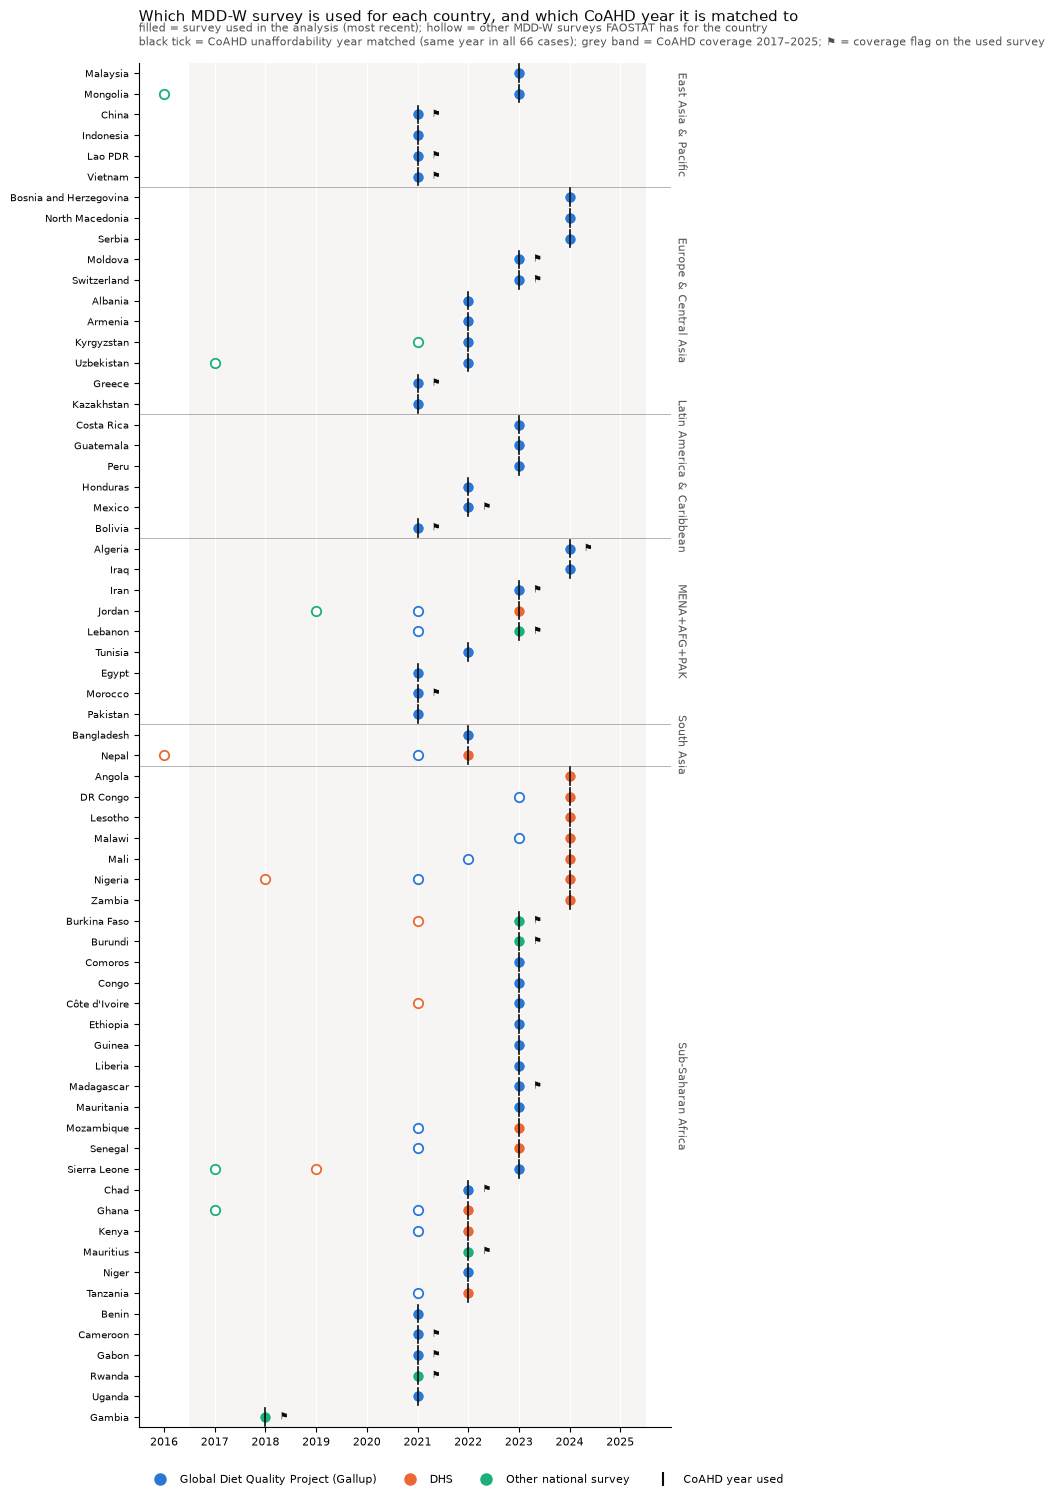

In [2]:
SHORT = {"Lao People's Democratic Republic": "Lao PDR", "United Republic of Tanzania": "Tanzania", "Iran (Islamic Republic of)": "Iran",
         "Bolivia (Plurinational State of)": "Bolivia", "Democratic Republic of the Congo": "DR Congo", "Republic of Moldova": "Moldova",
         "Viet Nam": "Vietnam", "China, mainland": "China"}
C = {"GDQP": "#2a78d6", "DHS": "#eb6834", "Other": "#1baf7a"}   # validated 3-slot palette
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

# order rows by region, then by used-survey year, then name — so the platform/year pattern by region is visible
p = p.assign(label=p.country.replace(SHORT)).sort_values(["region", "mddw_year", "label"], ascending=[True, False, True]).reset_index(drop=True)
ypos = {iso: i for i, iso in enumerate(p.iso3)}

fig, ax = plt.subplots(figsize=(9, 15))
# CoAHD availability band (annual, 2017-2025) and region separators
ax.axvspan(2016.5, 2025.5, color=GRID, alpha=.35, lw=0, zorder=0)
for reg, g in p.groupby("region", sort=False):
    y0, y1 = g.index.min(), g.index.max()
    ax.axhspan(y0 - .5, y1 + .5, color="none", lw=0)
    ax.text(2026.1, (y0 + y1) / 2, reg.replace("Middle East, North Africa, Afghanistan & Pakistan", "MENA+AFG+PAK"),
            rotation=270, va="center", ha="left", fontsize=8, color=MUTED)
    if y1 + .5 < len(p) - .5: ax.axhline(y1 + .5, color=MUTED, lw=.5, alpha=.6)

# all available surveys (hollow), then the used one (filled), then the CoAHD tick and flag
for _, r in m.iterrows():
    ax.scatter(r.year, ypos[r.iso3], s=46, facecolor="white", edgecolor=C[r.source_group], lw=1.3, zorder=2)
for _, r in p.iterrows():
    ax.scatter(r.mddw_year, ypos[r.iso3], s=70, color=C[r.mddw_source_group], edgecolor="white", lw=.8, zorder=3)
    ax.plot([r.pua_year, r.pua_year], [ypos[r.iso3] - .42, ypos[r.iso3] + .42], color=INK, lw=1.2, zorder=4)
    if r.any_flag:
        ax.text(r.mddw_year + .28, ypos[r.iso3], "⚑", fontsize=7, color=INK, va="center", zorder=5)

ax.set_yticks(range(len(p))); ax.set_yticklabels(p.label, fontsize=7.5); ax.invert_yaxis()
ax.set_xlim(2015.5, 2026); ax.set_xticks(range(2016, 2026)); ax.tick_params(axis="x", labelsize=8)
ax.set_ylim(len(p) - .5, -.5)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(axis="x", color="white", lw=1, zorder=1)
ax.set_title("Which MDD-W survey is used for each country, and which CoAHD year it is matched to", loc="left", fontsize=11, color=INK, pad=30)
ax.text(0, 1.01, "filled = survey used in the analysis (most recent); hollow = other MDD-W surveys FAOSTAT has for the country\n"
        "black tick = CoAHD unaffordability year matched (same year in all 66 cases); grey band = CoAHD coverage 2017–2025; ⚑ = coverage flag on the used survey",
        transform=ax.transAxes, fontsize=8, color=MUTED, va="bottom")
from matplotlib.lines import Line2D
h = [Line2D([], [], marker="o", ls="", ms=8, color=C[k], label=lab) for k, lab in
     [("GDQP", "Global Diet Quality Project (Gallup)"), ("DHS", "DHS"), ("Other", "Other national survey")]]
h.append(Line2D([], [], marker="|", ls="", ms=10, mew=1.5, color=INK, label="CoAHD year used"))
ax.legend(handles=h, frameon=False, fontsize=8, loc="lower left", bbox_to_anchor=(0, -0.05), ncol=4)
plt.tight_layout()
fig.savefig("../figures/fig3_survey_provenance.png", dpi=200, bbox_inches="tight")

## The same information as a table

In [3]:
alts = m.groupby("iso3").apply(lambda g: "; ".join(f"{int(y)} {s} ({v:.0f}%)" for y, s, v in zip(g.year, g.source_group, g.mddw)), include_groups=False)
tab = p[["label", "region", "mddw_year", "mddw_source_group", "mddw_source", "mddw", "pua_year", "pua", "excluded_pct", "mode", "any_flag"]].copy()
tab["all_surveys_available"] = p.iso3.map(alts)
pd.set_option("display.max_rows", 100, "display.width", 250, "display.max_colwidth", 80)
tab.rename(columns={"label": "country", "mddw_year": "MDD-W year used", "mddw_source_group": "platform", "mddw": "MDD-W %", "pua_year": "CoAHD year", "pua": "PUA %"})

,country,region,MDD-W year used,platform,mddw_source,MDD-W %,CoAHD year,PUA %,excluded_pct,mode,any_flag,all_surveys_available
0,Malaysia,East Asia & Pacific,2023,GDQP,Global Diet Quality Project,62.94,2023,1.9,0.0,Face-to-face,False,2023 GDQP (63%)
1,Mongolia,East Asia & Pacific,2023,GDQP,Global Diet Quality Project,55.10,2023,36.6,0.0,Face-to-face,False,2016 Other (70%); 2023 GDQP (55%)
2,China,East Asia & Pacific,2021,GDQP,Global Diet Quality Project,86.24,2021,16.6,1.0,Mobile telephone,True,2021 GDQP (86%)
3,Indonesia,East Asia & Pacific,2021,GDQP,Global Diet Quality Project,86.13,2021,69.7,0.0,Face-to-face,False,2021 GDQP (86%)
4,Lao PDR,East Asia & Pacific,2021,GDQP,Global Diet Quality Project,73.37,2021,56.6,14.0,Face-to-face,True,2021 GDQP (73%)
5,Vietnam,East Asia & Pacific,2021,GDQP,Global Diet Quality Project,88.67,2021,9.6,0.0,Mobile telephone,True,2021 GDQP (89%)
6,Bosnia and Herzegovina,Europe & Central Asia,2024,GDQP,Global Diet Quality Project,75.81,2024,12.7,0.0,Face-to-face,False,2024 GDQP (76%)
7,North Macedonia,Europe & Central Asia,2024,GDQP,Global Diet Quality Project,79.29,2024,16.1,0.0,Face-to-face,False,2024 GDQP (79%)
8,Serbia,Europe & Central Asia,2024,GDQP,Global Diet Quality Project,87.81,2024,9.4,0.0,Face-to-face,False,2024 GDQP (88%)
9,Moldova,Europe & Central Asia,2023,GDQP,Global Diet Quality Project,78.95,2023,15.0,13.0,Face-to-face,True,2023 GDQP (79%)
